# Notebook that allows to open single hdf5 file and perform routine operation

You can plot PSDs, calculate mode temperatures, calculate strain sensitivities, convert into strain, filter the data, inject fake signals to test the filtering, generate a pickle with event catalogue upon filtering

## Imports

In [3]:
import h5py
import numpy as np
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import os
from os import listdir
from scipy import signal
from scipy.signal import welch, csd
from scipy.signal import find_peaks
import lmfit
from scipy.fft import fft, fftfreq
import nexusformat.nexus as nx
import scipy.constants
from lmfit.models import LorentzianModel, ConstantModel
import sys
import os


## Opening file and retrieving data
Make sure you modify appropriately the folders here, where all data will be retrieved from

In [6]:
run = 3
subrun = 780
NFFT = 2**13

#filepath = '/home/leo_maria/Desktop/UWA/MAGE/MAGE4/run' + str(run) + '/run' + str(run) + '-' + str(subrun) + '.hdf5' # for run !=2 # where your hdf5 files are
filepath =  r'C:/Users/21958742/MAGE/MAGE4/run' + str(run) + '/run' + str(run) + '-' + str(subrun) + '.hdf5'  #for run 2

calibration_folder = 'C:/Users/21958742/MAGE/MAGE4/calibration'  # where your calibration data is

# Specify the absolute path to the 'libraries' directory, where Analysis_functions is
library_path = 'C:/Users/21958742/MAGE/libraries/'  # Adjust this to the actual absolute path
sys.path.append(library_path)
import Analysis_functions

In [7]:
Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file(filepath) 
iq = Analysis_functions.retrieve_IQ_td(filepath)
file_start = t_start + timedelta(seconds = subrun*Nsamples*dt)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
time = np.linspace(0, Nsamples*dt, Nsamples)

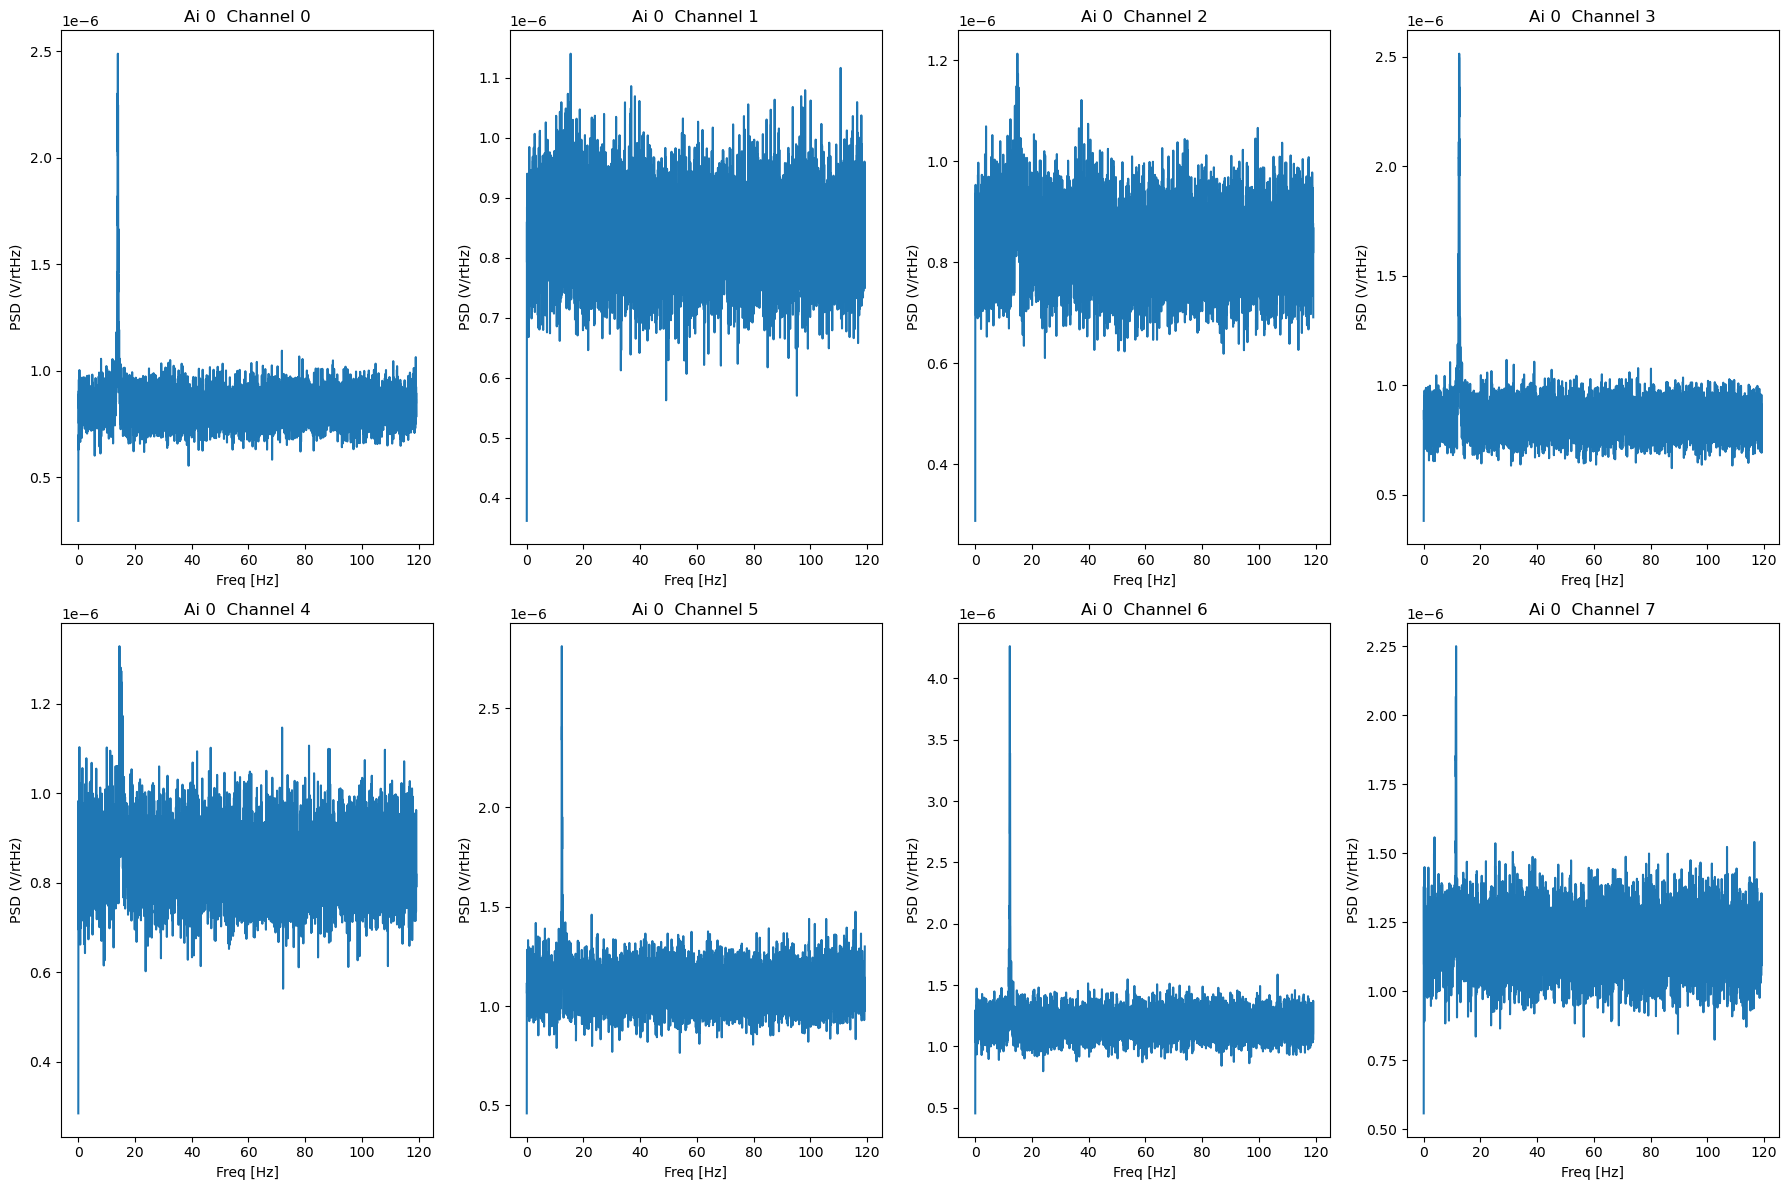

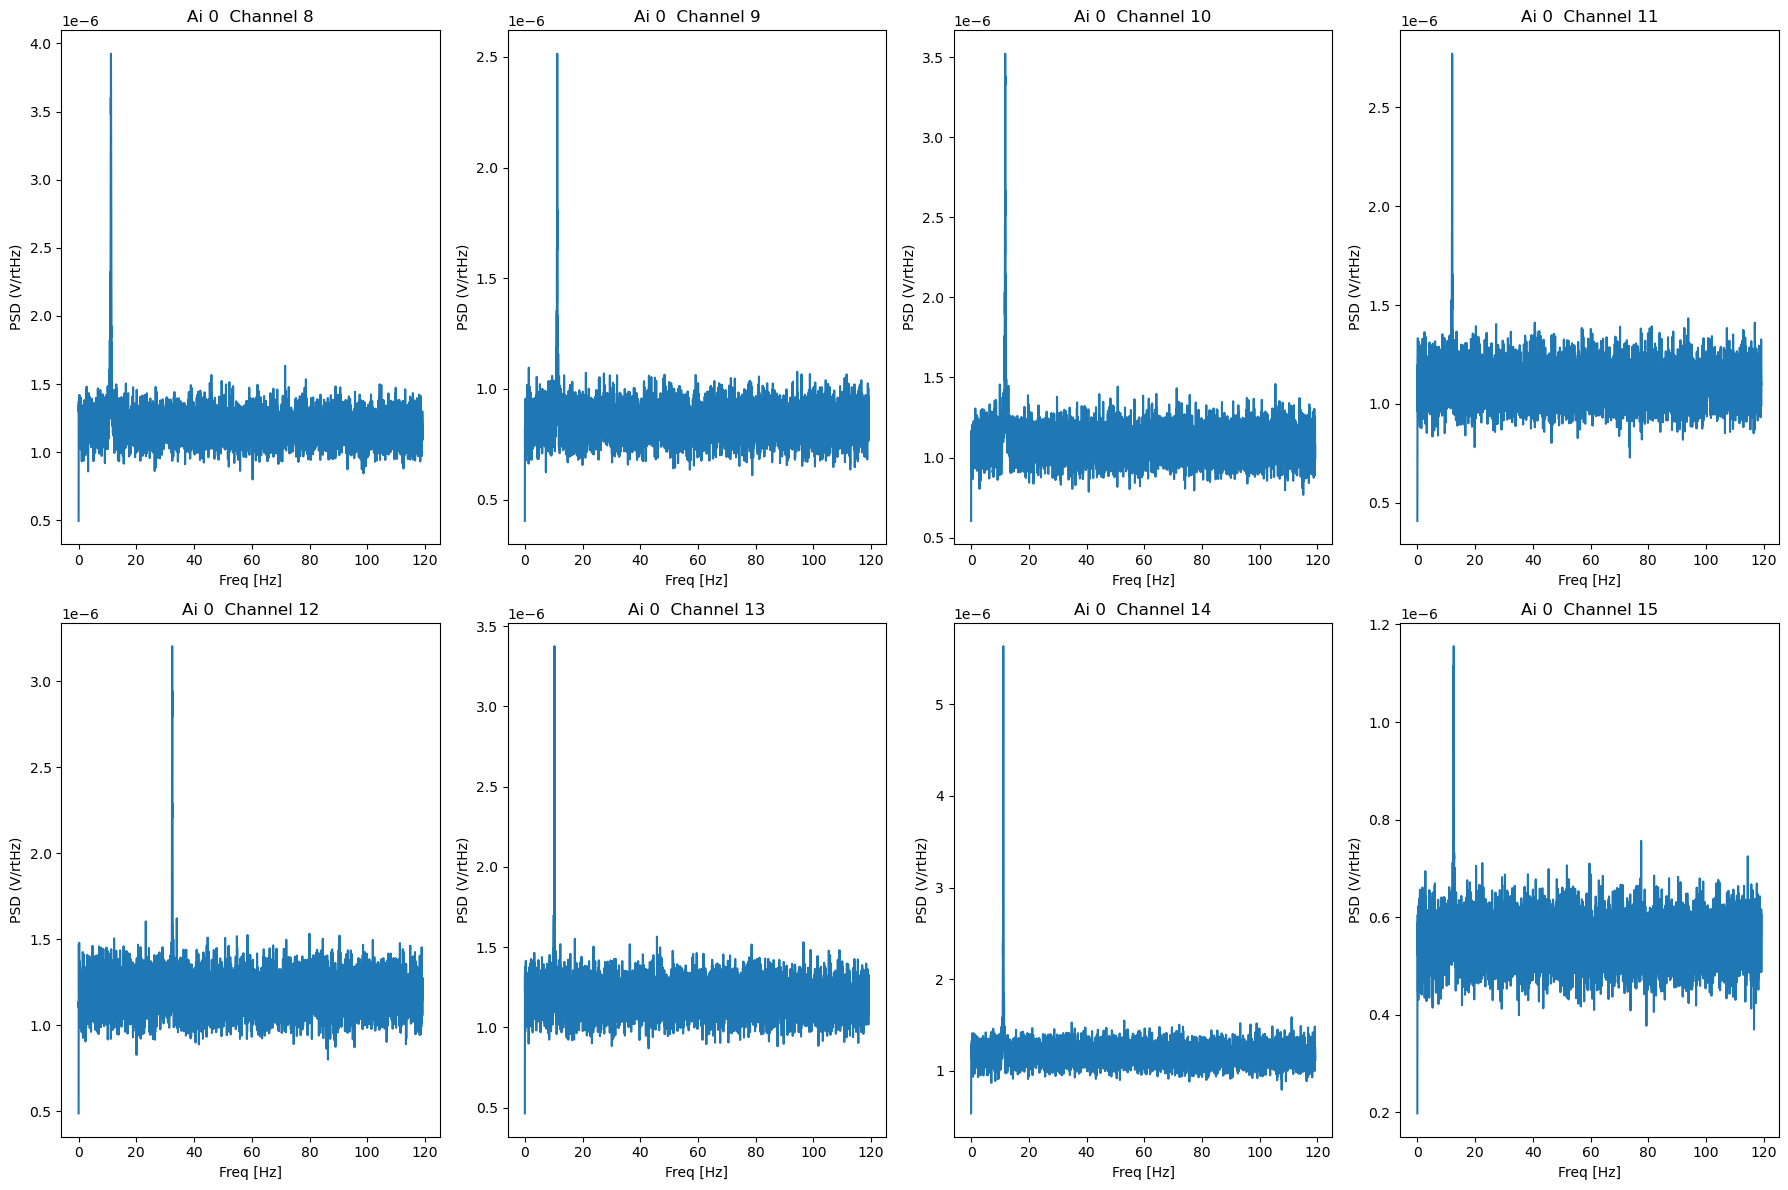

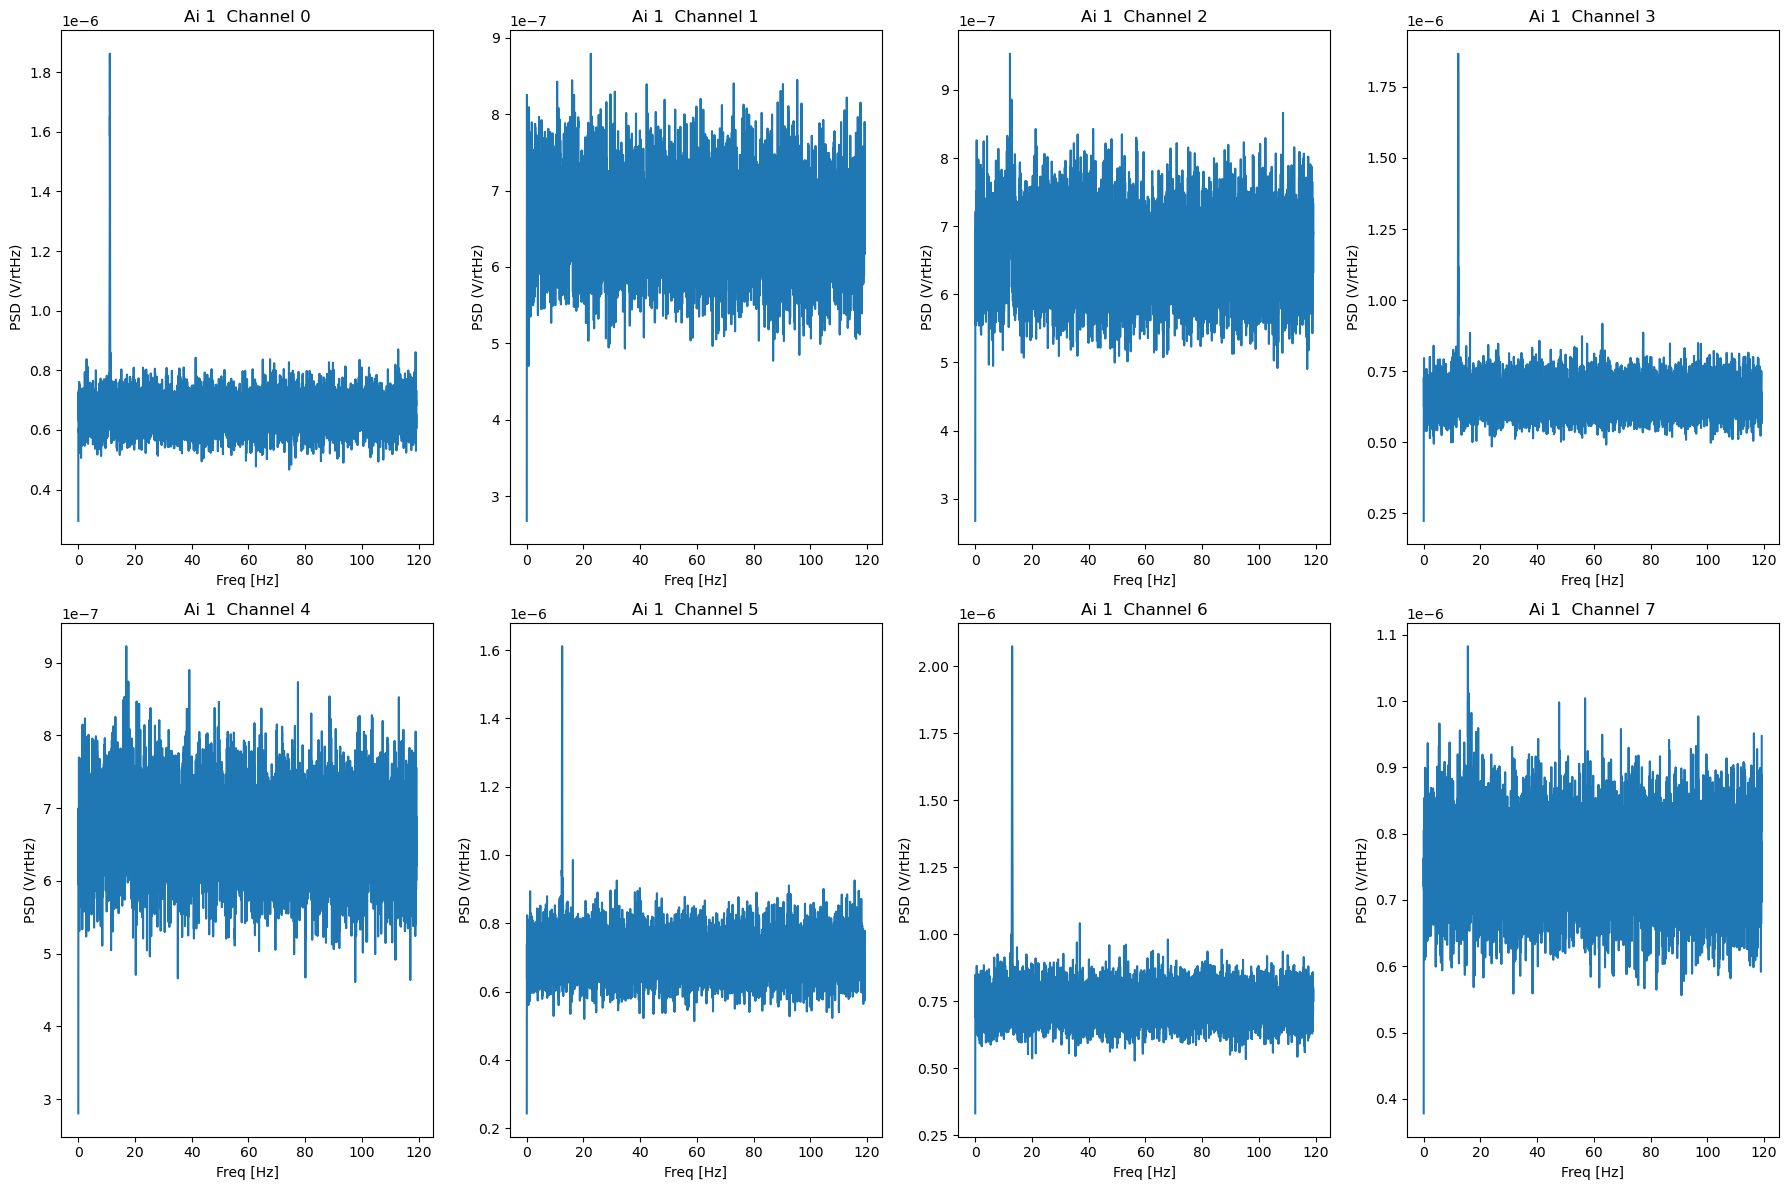

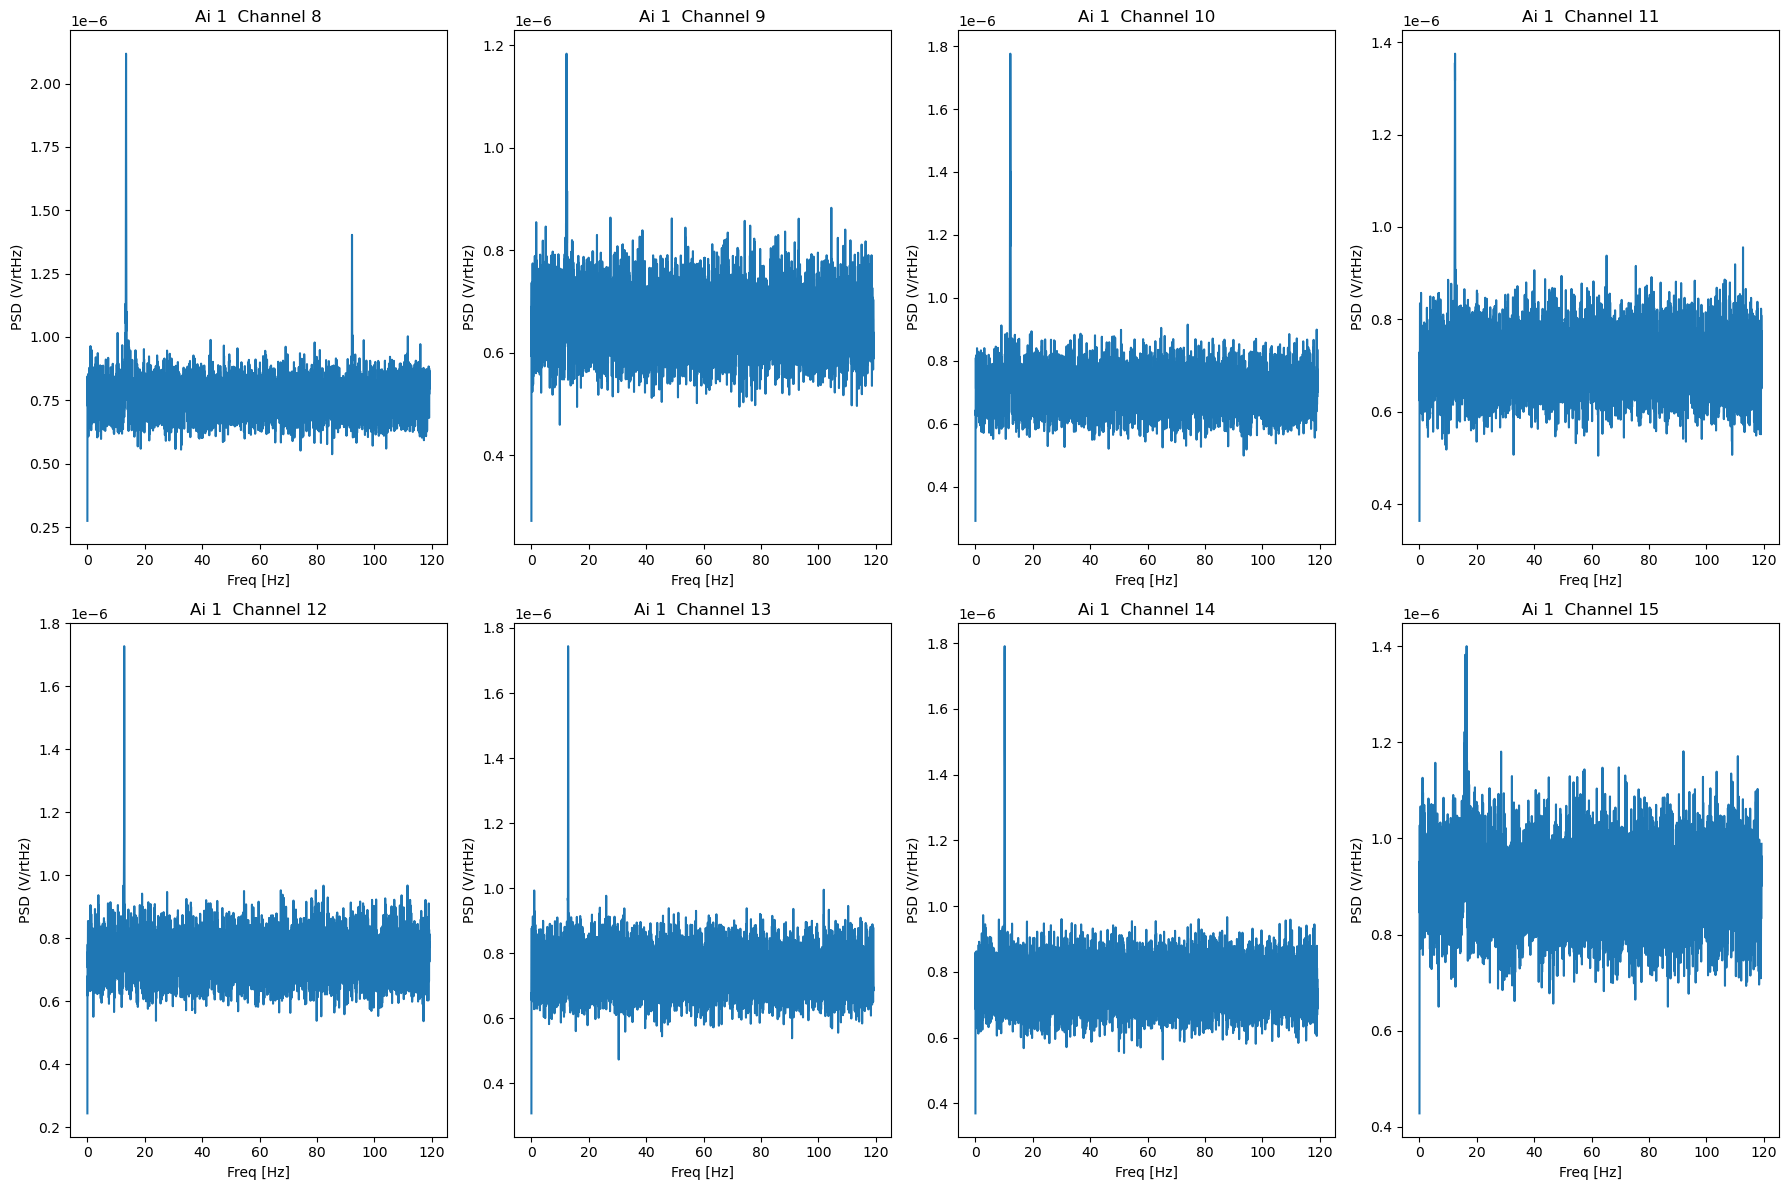

In [25]:

# Create subplots with 8 subplots per figure (2 rows and 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(18, 12))  # Create a 2x4 grid of subplots
axes = axes.flatten()  # Flatten the 2D axes array for easy indexing

plot_idx = 0  # To index through the subplots
for ai in [0, 1]:
    for ch in range(Nchannels):
        # Ensure you don't exceed the number of available subplots (8 in this case)
        if plot_idx >= len(axes):
            plt.tight_layout()  # Adjust layout when max subplots reached
            plt.show()           # Show the current figure
            fig, axes = plt.subplots(2, 4, figsize=(18, 12))  # Create a new figure with 8 subplots
            axes = axes.flatten()  # Flatten the axes for easy indexing
            plot_idx = 0  # Reset plot index for new figure

        ax = axes[plot_idx]  # Select the current axis for plotting
        ax.plot(freqs[ai, ch, :], np.sqrt(Sx[ai, ch, :]))
        ax.set_xlabel('Freq [Hz]')
        ax.set_ylabel('PSD (V/rtHz)')
        ax.set_title(f'Ai {ai}  Channel {ch}')
        #ax.set_yscale('log')
        #ax.set_xscale('log')
        plot_idx += 1  # Move to the next subplot index

# Final display of the last figure if not already shown
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


## Fit of thermal peaks

In [9]:
# Try and fit 

f_res = np.zeros((Ninputs,Nchannels))
sigmas = np.zeros_like(f_res)
integrals = np.zeros_like(f_res)
Qs = np.zeros_like(f_res)
const = np.zeros_like(f_res)
const_maxima = np.zeros_like(f_res)
f_res_err = np.zeros((Ninputs,Nchannels))
sigmas_err = np.zeros_like(f_res)
Qs_err = np.zeros_like(f_res)
const_err = np.zeros_like(f_res)

for ai in range(Ninputs):
    for ch in range(Nchannels):
        f_res[ai,ch], sigmas[ai,ch], integrals[ai,ch], Qs[ai,ch], const[ai,ch], f_res_err[ai,ch], sigmas_err[ai,ch], Qs_err[ai,ch], const_err[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=500, stop=1300)
        const_maxima[ai, ch] = integrals[ai, ch] / np.pi / sigmas[ai, ch] + const[ai, ch]

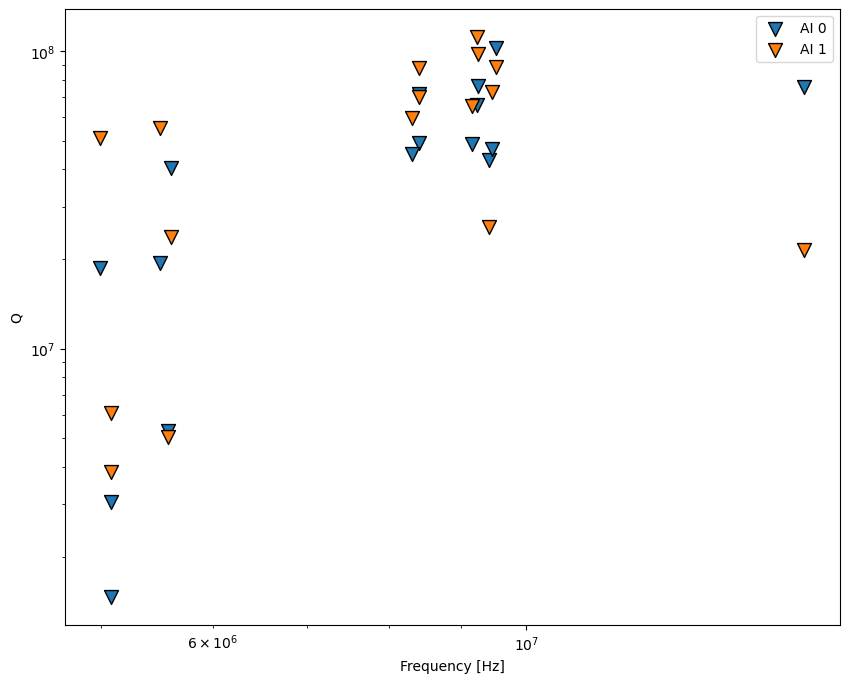

In [10]:
plt.figure(figsize=(10,8))
for ai in [0,1]:
    plt.scatter(x=f_res[ai,:],y=Qs[ai,:], label='AI ' + str(ai), marker='v', edgecolor='black', s=100)
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Q')

## Calculating mode temperatures

In [11]:
# import calibration
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])

Vphi = read_two_column_data(calibration_folder + '/Vphi_squids_quartz_order.txt')
Rbaw = read_two_column_data(calibration_folder + '/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
temperatures = np.zeros((Ninputs, Nchannels))



In [12]:
for ai in [0,1]:
    temperatures[ai, :] = (Rbaw[ai, :]**2 + (2*np.pi *f_res[ai,:] * Lin)**2 ) / (4 * k * Rbaw[ai, :] * (2000 * Vphi[ai, :] * Min[ai])**2 ) * const_maxima[ai, :]
print(const_maxima)


[[5.368359e-12 8.129634e-13 1.034957e-12 ... 1.066885e-11 3.244096e-11
  1.294368e-12]
 [3.057000e-12 5.234499e-13 6.053085e-13 ... 3.035084e-12 3.198245e-12
  1.444772e-12]]


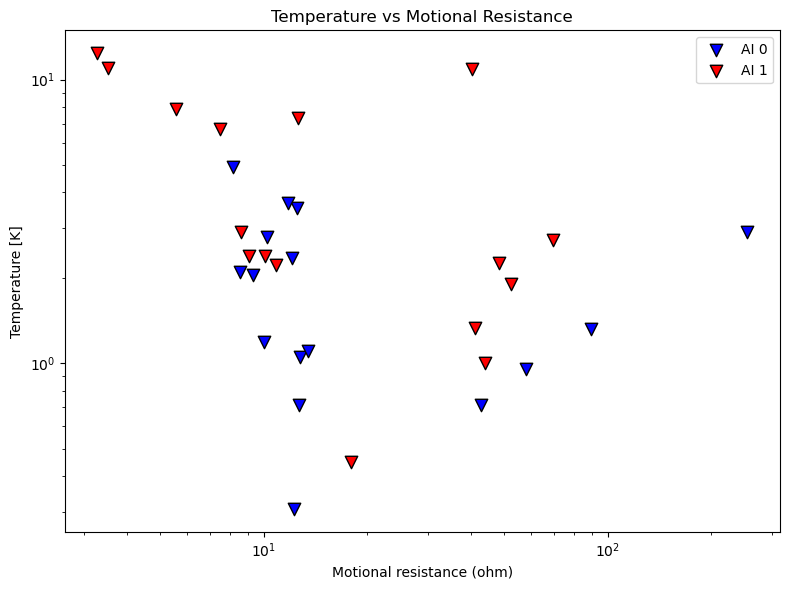

In [13]:

# Example data (replace these with your actual data)
# Rbaw = np.array([[...], [...]])  # 2D array
# temperatures = np.array([[...], [...]])  # 2D array

fig, ax = plt.subplots(figsize=(8, 6))  # One axis for the plot
colors = ['blue', 'red']

# Plot both datasets for ai = 0 and ai = 1 on the same plot
for ai in [0, 1]:
    ax.scatter(Rbaw[ai, :], temperatures[ai, :], c=colors[ai], edgecolor='black', marker='v', s=80, label=f'AI {ai}')

# Set labels and title
ax.set_xlabel('Motional resistance (ohm)')
ax.set_ylabel('Temperature [K]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Temperature vs Motional Resistance')

# Add a legend to distinguish between ai = 0 and ai = 1
ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


## Estimation of strain sensitivity from mode temps / PSD

Use the formula $$S_h^+ (\omega_{\lambda} ) = \frac{2 \sqrt{S_v(\omega_{\lambda})}}{\kappa_{\lambda} \omega_{\lambda} Q_{\lambda} R_{\lambda} h_0 \xi_{\lambda}}.$$

That's from MAGE paper, apart from a factor 2 that must have been lost somewhere in the calculations. In the paper from PRD the facttor 2 is there.


In [14]:
def strain_sens(psd_VperrtHz, kappa, freq, Q, R, h, xi):
    return 2 * psd_VperrtHz / (kappa * 2*np.pi * freq * Q * R * h * xi)

feffective_mass = open(calibration_folder + '/Meff.txt')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

kappa=np.zeros((Ninputs, Nchannels))
for ai in range(Ninputs):
    for ch in range(Nchannels):
        kappa[ai, ch] = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))

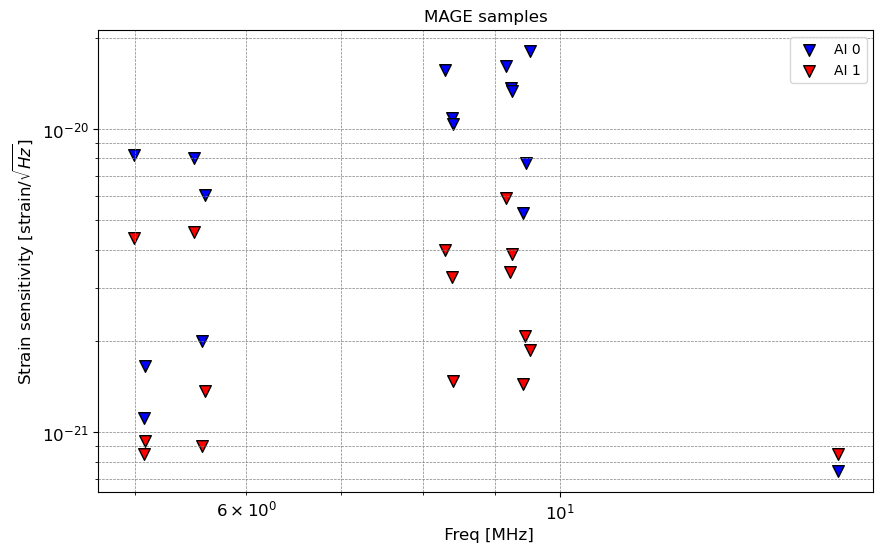

In [15]:
plt.figure(figsize=(10,6))
sensitivities = np.zeros((Ninputs, Nchannels))
for ai in range(Ninputs):
    for ch in range(Nchannels):
        sensitivities[ai,ch] = strain_sens(const_maxima[ai,ch], kappa[ai,ch], f_res[ai,ch], Qs[ai,ch], Rbaw[ai,ch], 1e-3, xi[ch] )
    plt.scatter(f_res[ai, :]/1e6, sensitivities[ai, :], label = 'AI ' + str(ai), marker = 'v', s = 70, color = colors[ai], edgecolor='black')
    plt.xlabel(' Freq [MHz]', fontsize=12)
    plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=14)
    plt.ylabel(r'Strain sensitivity [strain/$\sqrt{Hz}$]', fontsize=12)
    plt.tick_params(axis='both', which='both', labelsize=12)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('MAGE samples')
    plt.legend()

Rakon [ 5725443. 19880834. 58681143. 27908919. 23976187. 58537395.]
MAGE samples [18627249.02132  19464477.169104 48704591.018276 46841257.603474
 45154171.363778 75877233.441149]


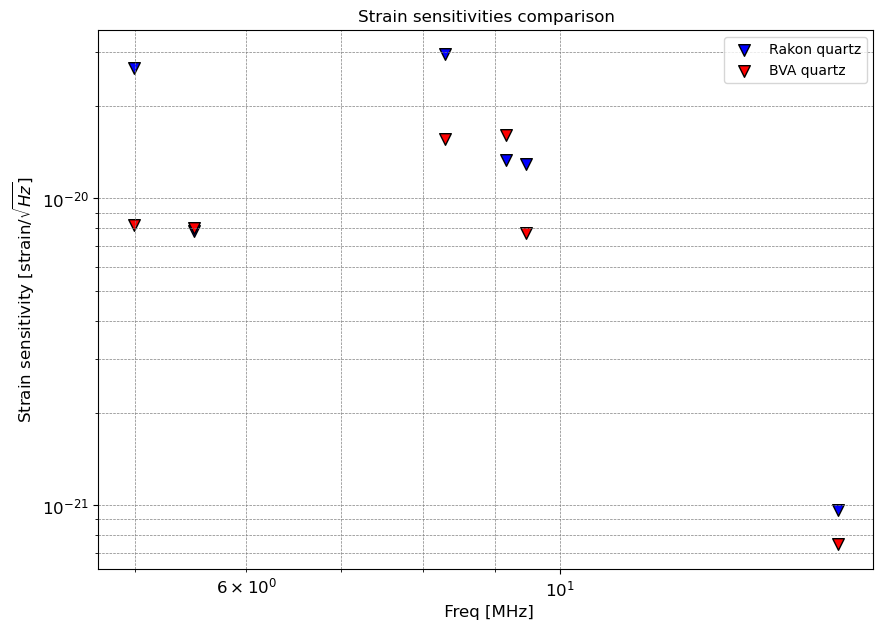

freq:  4993040.933507108 	 BVA ss:  8.183292056732645e-21 	 RAKON ss:  2.6623654965205522e-20
freq:  5505680.503185503 	 BVA ss:  8.02928618119547e-21 	 RAKON ss:  7.86113185986452e-21
freq:  9152222.19879473 	 BVA ss:  1.607662468685792e-20 	 RAKON ss:  1.3343390913972684e-20
freq:  9453789.206791935 	 BVA ss:  7.729012852002372e-21 	 RAKON ss:  1.2972078281541496e-20
freq:  8297611.832746898 	 BVA ss:  1.56641792439193e-20 	 RAKON ss:  2.950023011802772e-20
freq:  15734388.55565976 	 BVA ss:  7.45885274405215e-22 	 RAKON ss:  9.66830025257533e-22


In [16]:
# Projection for RAKON baw
# In first approx I can only change the Q and keep the rest all the same
# I only use the modes with m,p=0 bc they are the only ones I can compare with MAGE modes

rakon_freqs = np.array([5.167938e6, 5.689650e6, 9.464160e6, 9.741672e6, 8.593911e6, 16.218814e6])
rakon_Qs = np.array([5725443.0, 19880834.0, 58681143.0, 27908919.0, 23976187.0, 58537395.0])
rakon_indices = np.array([0, 3, 6, 8, 10, 15])

plt.figure(figsize=(10,7))
rakon_sensitivities = np.zeros(rakon_indices.size)
ai = 0
for integer, ch in enumerate(rakon_indices):
    rakon_sensitivities[integer] = strain_sens(const_maxima[ai,ch], kappa[ai,ch], f_res[ai,ch], rakon_Qs[integer], Rbaw[ai,ch], 1e-3, xi[ch] )
plt.scatter(f_res[ai, rakon_indices]/1e6, rakon_sensitivities, label = 'Rakon quartz', marker = 'v', s = 70, color = colors[ai], edgecolor='black')
plt.scatter(f_res[ai, rakon_indices]/1e6, sensitivities[ai,rakon_indices], label = 'BVA quartz ', marker = 'v', s = 70, color = colors[ai+1], edgecolor='black')

plt.xlabel(' Freq [MHz]', fontsize=12)
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')
plt.legend(fontsize=14)
plt.ylabel(r'Strain sensitivity [strain/$\sqrt{Hz}$]', fontsize=12)
plt.tick_params(axis='both', which='both', labelsize=12)
plt.xscale('log')
plt.yscale('log')
plt.title('Strain sensitivities comparison')
plt.legend()
print('Rakon', rakon_Qs)
print('MAGE samples', Qs[ai, rakon_indices])
plt.show()
for i in range(rakon_indices.size):
    print('freq: ', f_res[ai, rakon_indices[i]], '\t BVA ss: ', sensitivities[ai,rakon_indices[i]], '\t RAKON ss: ', rakon_sensitivities[i])

## Injecting a fake signal


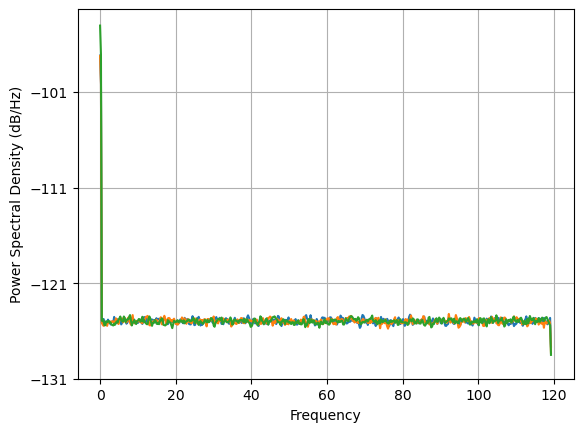

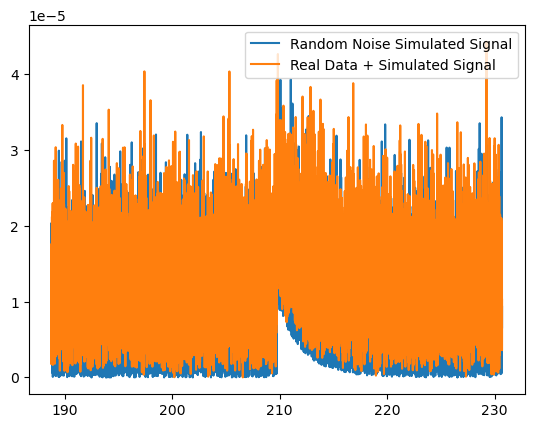

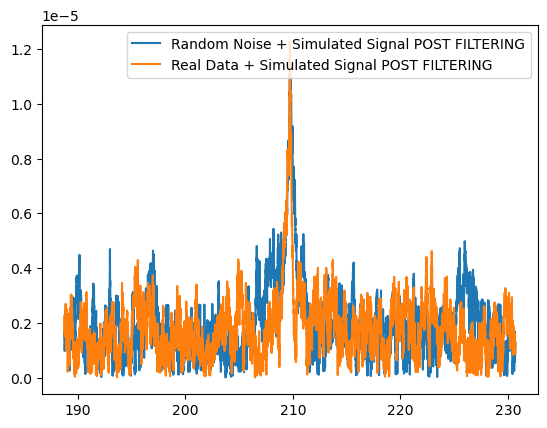

In [17]:
# CHECK IF FILTERING MAKES SENSE
ai = 0
channel = 9
Rdat = np.sqrt(iq[ai, channel, 0, :]**2 + iq[ai, channel, 1, :]**2)

# Generate the template signal
signal, t_sig, tau = Analysis_functions.generate_template(ai, channel, f_res, Qs, Fs, dt, Nsamples)

# Pad and roll the signal
template_pad = Analysis_functions.pad_and_roll_signal(signal, Rdat)

# Add noise to the signal
h_inject, h_inject2, h_inject3 = Analysis_functions.add_noise_to_signal(template_pad, Rdat)

# Apply the optimal filter
SNR, dat_filt = Analysis_functions.optimal_filter(h_inject, signal, Fs, NFFT=1024)
SNR2, dat_filt2 = Analysis_functions.optimal_filter(h_inject2, signal, Fs, NFFT=1024)
SNR3, dat_filt3 = Analysis_functions.optimal_filter(h_inject3, signal, Fs, NFFT=1024)
plt.show()
# Plot the results
nn = 50000
span = 10000
Analysis_functions.plot_filtered_data(tn=np.linspace(0, Nsamples*dt, Nsamples), nn=nn, span=span, h_inject=h_inject, h_inject3=h_inject3, dat_filt=dat_filt, dat_filt3=dat_filt3)



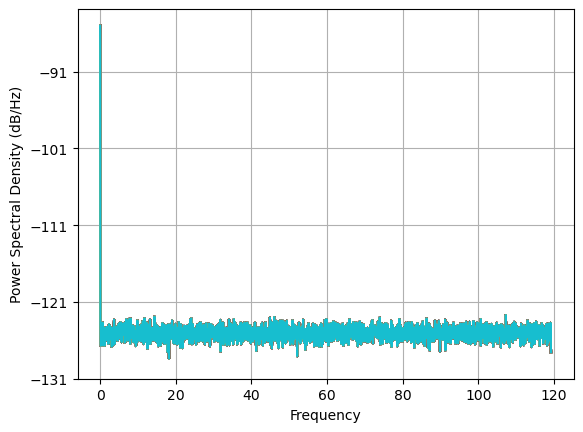

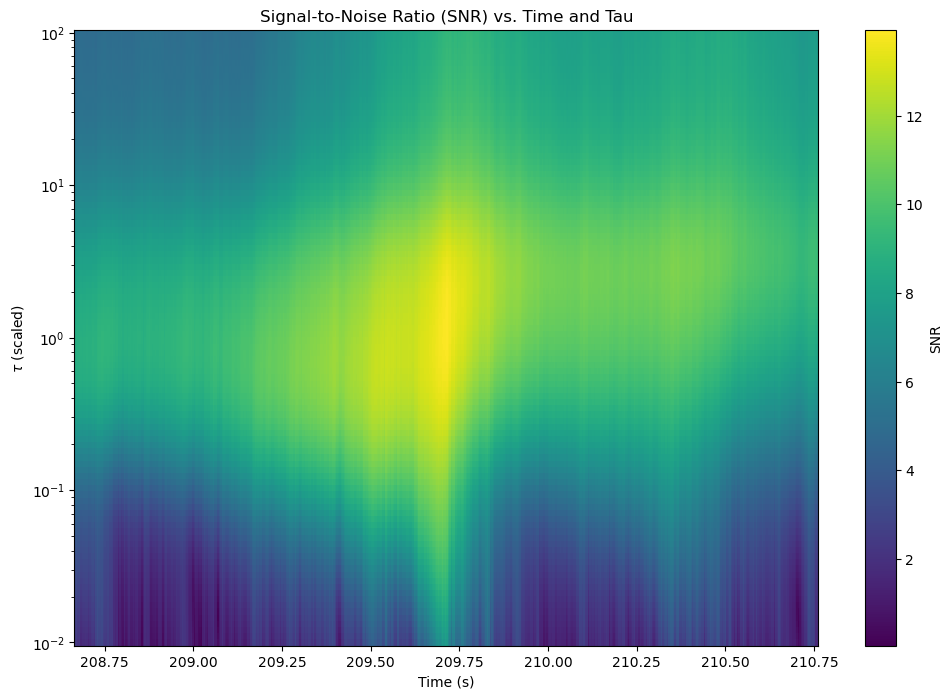

Text(0, 0.5, 'Max SNR at signal arrival')

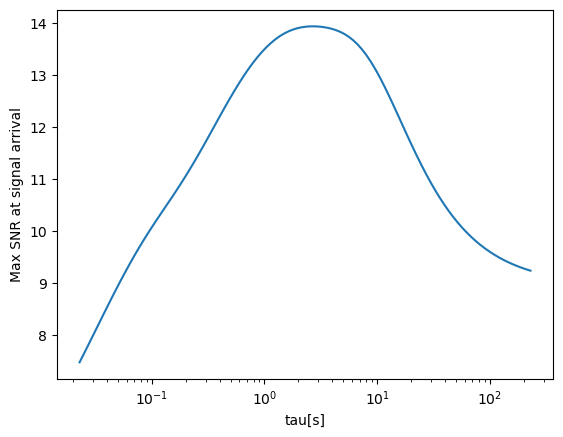

In [18]:
# meshgrid with results for different values of tau
Ntemplates = 100
Span = 500
SNR_arr = np.zeros((Ntemplates, Span))
tau_vec = tau*np.logspace(-2,2,Ntemplates)
for i in range(Ntemplates):
    template = np.exp(-t_sig/(tau_vec[i]))
    SNR, dat_filt = Analysis_functions.optimal_filter(h_inject3, template, Fs, NFFT)
    SNR_arr[i,:] = SNR[nn-Span//2:nn+Span//2]

Analysis_functions.plot_snr_colormesh(SNR_arr, tau_vec, time, nn, Span, tau, Fs, NFFT)
plt.plot(tau_vec, SNR_arr[:,Span//2])
plt.xscale('log')
plt.xlabel('tau[s]')
plt.ylabel('Max SNR at signal arrival')

Seems to make sense now:
you get maximized snr for the correct time constant

## Filtering the data

## Conversion into strain

Calculated that:
$\begin{equation}
    u(\omega) = \frac{1}{M_{in}(-j\omega)\kappa_{\lambda}} \frac{1}{2000 V_{\Phi}(\omega)} V(\omega)
\end{equation}$
If I use $R(\omega)$ as $V_{\omega}$, the strain I get is a time series (after ifft) of amplitude of strain at frequency at $\omega_{\text signal}$.\
Careful: $\omega$ here must be the high frequency (you need to add demodulation
)

In [19]:
R=np.zeros_like(iq[:,:,0,:])
kappa=np.zeros((Ninputs, Nchannels))
strain = np.zeros_like(R)

meff = Analysis_functions.get_eff_mass('/home/leo_maria/Desktop/UWA/MAGE/MAGE4/calibration/Meff.txt')

for ai in range(Ninputs):
    for ch in range(Nchannels):
        R[ai,ch,:] = np.sqrt(iq[ai, ch, 0, :]**2 + iq[ai,ch,1,:]**2)
        kappa[ai, ch] = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
        strain[ai,ch] = Analysis_functions.R_to_strain(R[ai,ch,:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa[ai,ch])

plt.plot(time, strain[0,2])


FileNotFoundError: [Errno 2] No such file or directory: '/home/leo_maria/Desktop/UWA/MAGE/MAGE4/calibration/Meff.txt'

### Filter

C:\Users\21958742\AppData\Local\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:7237: RuntimeWarning: divide by zero encountered in log10
  line = self.plot(freqs, 10 * np.log10(pxx), **kwargs)
C:\Users\21958742\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\Analysis_functions.py:30: RuntimeWarning: divide by zero encountered in divide
  OF = np.fft.ifft(fft_template*fft_template.conjugate()/power_spec).real
C:\Users\21958742\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\Analysis_functions.py:30: RuntimeWarning: invalid value encountered in divide
  OF = np.fft.ifft(fft_template*fft_template.conjugate()/power_spec).real
C:\Users\21958742\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\Analysis_functions.py:549: ComplexWarning: Casting complex values to real discards the imaginary part
  SNR[ai,ch], filtered_strain[ai,ch] = optimal_filter(strain[ai,ch], template, Fs, NFFT)


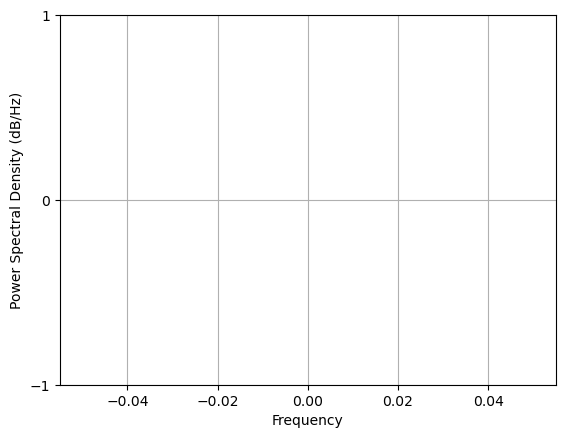

In [20]:

tau=np.zeros((Ninputs,Nchannels))
tau = Qs /np.pi / f_res # Decay constant, assumed formula


SNR, filtered_strain, event_catalogue = Analysis_functions.filter_strain_data_one_file(strain, tau, Fs, NFFT, file_start, fdemods, subrun)

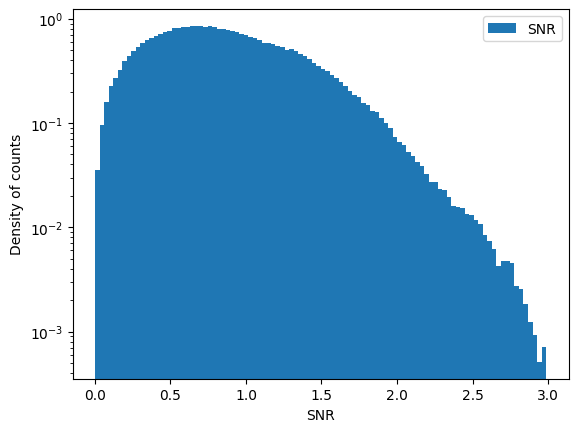

In [26]:
plt.hist(SNR[0,0], bins=100, label= 'SNR', density=True)
#plt.hist(np.abs(filtered_strain[0,0]), bins=100, label = ' u filtered rms', density=True)
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('Density of counts')
plt.legend()